In [3]:

!pip install feedparser yfinance transformers torch numpy pandas scikit-learn matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import yfinance as yf
import feedparser
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from urllib.parse import quote
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:

print("Loading FinBERT model...")
tokenizer=AutoTokenizer.from_pretrained("yiyanghkust/finbert-tone")
finbert=AutoModelForSequenceClassification.from_pretrained("yiyanghkust/finbert-tone").to(device)

def get_finbert_sentiment(text):
    if not text or len(text) < 5: return 0.0
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = finbert(**inputs)
    prediction = torch.nn.functional.softmax(outputs.logits, dim=-1)
    #Weighted score:Positive (index 1)-Negative (index 2)
    probs = prediction[0].cpu().numpy()
    return probs[1] - probs[2]

def fetch_daily_sentiment(query):
    print(f"Fetching news for: {query}...")
    rss_url = f"https://news.google.com/rss/search?q={quote(query)}"
    feed = feedparser.parse(rss_url)
    daily_scores = {}

    for entry in feed.entries[:100]:
        try:
            dt = pd.to_datetime(entry.published).strftime('%Y-%m-%d')
            score = get_finbert_sentiment(entry.title)
            if dt not in daily_scores:
                daily_scores[dt] = []
            daily_scores[dt].append(score)
        except Exception as e:
            continue

    # Average sentiment per day
    final_sentiment = {date: np.mean(scores) for date, scores in daily_scores.items()}
    df = pd.DataFrame(list(final_sentiment.items()), columns=['Date', 'Sentiment'])
    df['Date'] = pd.to_datetime(df['Date'])
    return df

# Fetch sentiment for AAPL
sentiment_df = fetch_daily_sentiment("AAPL")
print("Sentiment data fetched.")

Loading FinBERT model...
Fetching news for: AAPL...
Sentiment data fetched.


In [5]:

ticker = 'AAPL'
df = yf.download(ticker, start='2020-01-01')


if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df_reset = df.reset_index()
df_reset['Date'] = pd.to_datetime(df_reset['Date'])

#Merge with Sentiment
df_combined = pd.merge(df_reset, sentiment_df, on='Date', how='left')
df_combined['Sentiment'] = df_combined['Sentiment'].fillna(0)

#Prepare Data for Training
features = ['Close', 'Volume', 'Sentiment']
data_values = df_combined[features].values
dates = df_combined['Date'].values

train_size = int(0.8 * len(data_values))
train_data = data_values[:train_size]
test_data = data_values[train_size:]

#Scale Data
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)


price_scaler = StandardScaler()
price_scaler.fit(train_data[:, 0].reshape(-1, 1))


def create_sequences(data, seq_length):
    X_list, y_list = [], []
    for i in range(len(data) - seq_length):
        X_list.append(data[i:i+seq_length])
        y_list.append(data[i+seq_length, 0])
    return np.array(X_list), np.array(y_list).reshape(-1, 1)

seq_length = 30
X_train_np, y_train_np = create_sequences(train_data_scaled, seq_length)
X_test_np, y_test_np = create_sequences(test_data_scaled, seq_length)


x_train = torch.from_numpy(X_train_np).float().to(device)
y_train = torch.from_numpy(y_train_np).float().to(device)
x_test = torch.from_numpy(X_test_np).float().to(device)
y_test = torch.from_numpy(y_test_np).float().to(device)

print(f"Data prepared. Train shape: {x_train.shape}, Test shape: {x_test.shape}")

/tmp/ipython-input-3494400273.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01')
[*********************100%***********************]  1 of 1 completed

Data prepared. Train shape: torch.Size([1179, 30, 3]), Test shape: torch.Size([273, 30, 3])


In [6]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = PredictionModel(input_dim=3, hidden_dim=128, num_layers=2, output_dim=1)
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 150
for i in range(num_epochs):
    model.train()
    y_train_pred = model(x_train)
    loss = criterion(y_train_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 25 == 0:
        print(f"Epoch {i}, Loss: {loss.item():.6f}")

print("Training Complete.")

Starting Training...
Epoch 0, Loss: 0.939662
Epoch 25, Loss: 0.087937
Epoch 50, Loss: 0.020912
Epoch 75, Loss: 0.016472
Epoch 100, Loss: 0.014595
Epoch 125, Loss: 0.013544
Training Complete.


Test RMSE (Real Prices): $9.97


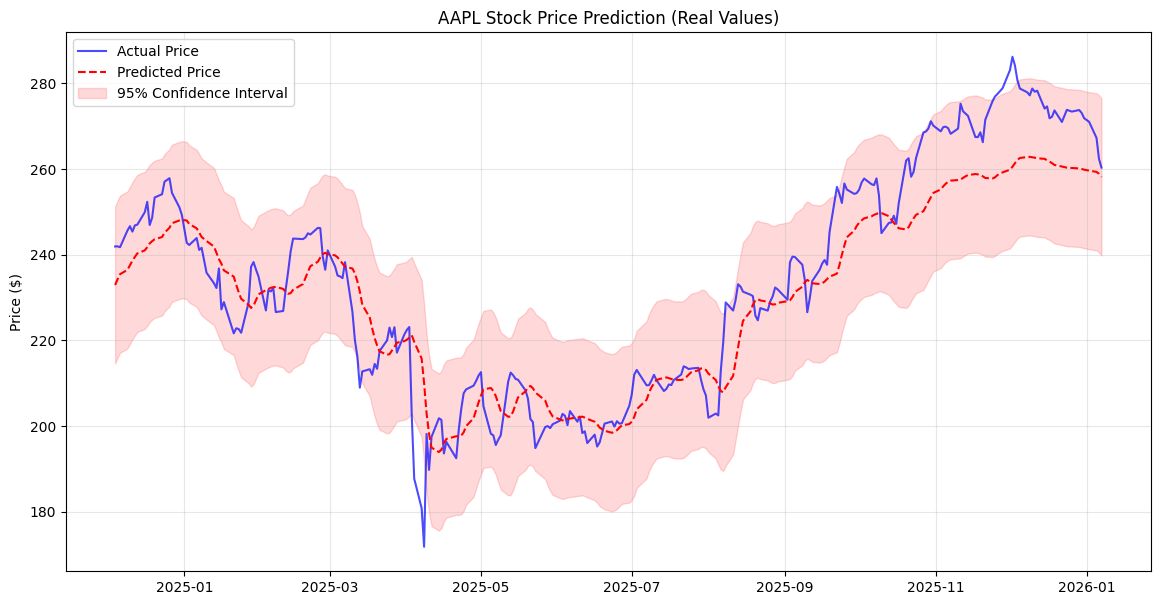

In [7]:
model.eval()
with torch.no_grad():
    y_train_pred_scaled = model(x_train)
    y_test_pred_scaled = model(x_test)

y_test_real = price_scaler.inverse_transform(y_test.cpu().numpy())
y_test_pred_real = price_scaler.inverse_transform(y_test_pred_scaled.cpu().numpy())

test_rmse = root_mean_squared_error(y_test_real, y_test_pred_real)
print(f"Test RMSE (Real Prices): ${test_rmse:.2f}")

test_start_idx = train_size + seq_length
test_dates = df_combined['Date'].iloc[test_start_idx : test_start_idx + len(y_test_real)].values


def plot_confidence_intervals(dates, y_true, y_pred, title):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    residuals = y_true - y_pred
    std_dev = np.std(residuals)

    upper_bound = y_pred + (1.96 * std_dev)
    lower_bound = y_pred - (1.96 * std_dev)

    plt.figure(figsize=(14, 7))
    plt.plot(dates, y_true, label='Actual Price', color='blue', alpha=0.7)
    plt.plot(dates, y_pred, label='Predicted Price', color='red', linestyle='--')
    plt.fill_between(dates, lower_bound, upper_bound, color='red', alpha=0.15, label='95% Confidence Interval')
    plt.title(title)
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_confidence_intervals(test_dates, y_test_real, y_test_pred_real, f"{ticker} Stock Price Prediction (Real Values)")

TRADING RESULTS (Start: $10000)
Final Portfolio Value: $9,360.90
AI Strategy Return:    -6.39%
Buy & Hold Return:     7.61%
Total Trades:          11


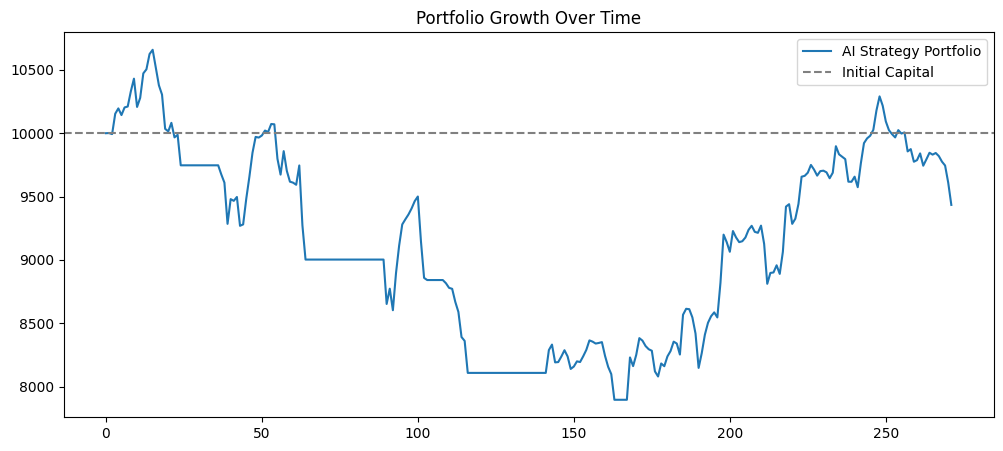

In [8]:
def simulate_trading_strategy(y_true, y_pred, initial_capital=10000, threshold=0.005):
    """
    Simulate trading based on REAL dollar values.
    Threshold 0.005 means we buy if predicted price is 0.5% higher than current.
    """
    capital = initial_capital
    shares = 0
    position = 'none'
    portfolio_values = []
    trades = 0

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    for i in range(len(y_true) - 1):
        current_price = y_true[i]
        next_pred_price = y_pred[i+1]

        #expected % change based on PREDICTION
        predicted_pct_change = (next_pred_price - y_pred[i]) / y_pred[i]

        # BUY Logic
        if predicted_pct_change > threshold and position == 'none':
            shares = capital / current_price
            capital = 0
            position = 'long'
            trades += 1

        # SELL Logic
        elif predicted_pct_change < -threshold and position == 'long':
            capital = shares * current_price
            shares = 0
            position = 'none'
            trades += 1

        # Track Value
        current_val = capital + (shares * current_price)
        portfolio_values.append(current_val)

    # Final Liquidation
    if position == 'long':
        capital = shares * y_true[-1]

    final_return = ((capital - initial_capital) / initial_capital) * 100
    buy_hold_return = ((y_true[-1] - y_true[0]) / y_true[0]) * 100

    print("="*40)
    print(f"TRADING RESULTS (Start: ${initial_capital})")
    print("="*40)
    print(f"Final Portfolio Value: ${capital:,.2f}")
    print(f"AI Strategy Return:    {final_return:.2f}%")
    print(f"Buy & Hold Return:     {buy_hold_return:.2f}%")
    print(f"Total Trades:          {trades}")

    plt.figure(figsize=(12, 5))
    plt.plot(portfolio_values, label='AI Strategy Portfolio')
    plt.axhline(initial_capital, color='grey', linestyle='--', label='Initial Capital')
    plt.title("Portfolio Growth Over Time")
    plt.legend()
    plt.show()


simulate_trading_strategy(y_test_real, y_test_pred_real)